In [2]:
import numpy as np 
import pandas as pd

In [3]:
results_aggregated = pd.read_csv("../package_metadata/results_strat_aggregation.csv")

In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

def estimate_coefficients(group):
    """
    We Fit log(mae) = log(C) - p * log(n)
    Returns a Series with p and C.
    """
    group = group.dropna(subset=['target_size', 'mae_mean'])
    group = group[(group['target_size'] > 0) & (group['mae_mean'] > 0)]
    
    if len(group) < 2: 
        return pd.Series({'p': np.nan, 'C': np.nan})

    log_n = np.log(group['target_size'].values).reshape(-1, 1)
    log_y = np.log(group['mae_mean'].values)
    
    model = LinearRegression()
    model.fit(log_n, log_y)
    
    p = -model.coef_[0]
    C = np.exp(model.intercept_)
    
    return pd.Series({'p': p, 'C': C})

group_cols = ["dataset_name", "model_name", "explainer_total", "method_total"]

coeffs_df = (
    results_aggregated
    .groupby(group_cols)
    .apply(estimate_coefficients)
    .reset_index()
)

print(coeffs_df)

                           dataset_name model_name     explainer_total  \
0     GesturePhaseSegmentationProcessed         nn  expected_gradients   
1     GesturePhaseSegmentationProcessed         nn  expected_gradients   
2     GesturePhaseSegmentationProcessed         nn  expected_gradients   
3     GesturePhaseSegmentationProcessed         nn  expected_gradients   
4     GesturePhaseSegmentationProcessed         nn  expected_gradients   
...                                 ...        ...                 ...   
1661                               wilt    xgboost       shapiq_kernel   
1662                               wilt    xgboost       shapiq_kernel   
1663                               wilt    xgboost       shapiq_kernel   
1664                               wilt    xgboost       shapiq_kernel   
1665                               wilt    xgboost       shapiq_kernel   

                 method_total         p         C  
0                       arfpy  0.469691  0.252005  
1      

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/3690814232.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_coefficients)


# Low level charts

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

os.makedirs("rates", exist_ok=True)

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_inverse_multiquadric": "#F5B027",
    "kt_sobolev": "gray",
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
    "kt_stratified": "#81b29a",
    "kt_predictions": "#f08060"
}

method_markers = {
    "iid": "o",
    "kt_gaussian": "v"
}

method_linestyles = {
    "iid": "-",
    "kt_gaussian": "--"
}

target_methods = ["iid", "kt_gaussian"]
results_filtered = results_aggregated[results_aggregated["method_total"].isin(target_methods)].copy()
results_filtered["config"] = results_filtered["model_name"] + " | " + results_filtered["explainer_total"]

all_unique_datasets = results_filtered["dataset_name"].unique()
eg_datasets = sorted([
    ds for ds in all_unique_datasets 
    if "expected_gradients" in results_filtered[results_filtered["dataset_name"] == ds]["explainer_total"].values
])
other_datasets = sorted([ds for ds in all_unique_datasets if ds not in eg_datasets])

def plot_custom_grid(dataset_list, filter_eg, filename):
    if not dataset_list:
        return
        
    subset_data = results_filtered[results_filtered["dataset_name"].isin(dataset_list)].copy()
    
    if filter_eg:
        subset_data = subset_data[subset_data["explainer_total"] == "expected_gradients"]
    else:
        subset_data = subset_data[subset_data["explainer_total"] != "expected_gradients"]
        
    configs = sorted(subset_data["config"].unique())
    n_rows = len(dataset_list)
    n_cols = len(configs)
    
    if n_cols == 0:
        return

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)
    
    for i, ds in enumerate(dataset_list):
        for j, cfg in enumerate(configs):
            ax = axes[i, j]
            ax.set_box_aspect(1)
            
            cell_data = subset_data[(subset_data["dataset_name"] == ds) & 
                                   (subset_data["config"] == cfg)]
            
            present_methods = []
            for method in target_methods:
                m_data = cell_data[cell_data["method_total"] == method].dropna(subset=['target_size', 'mae_mean']).sort_values("target_size")
                
                if len(m_data) < 2:
                    continue
                
                present_methods.append(method)
                n_vals = m_data['target_size'].values
                y_vals = m_data['mae_mean'].values
                
                color = method_colors.get(method, "black")
                marker = method_markers.get(method, "o")
                linestyle = method_linestyles.get(method, "-")
                
                log_n = np.log(n_vals).reshape(-1, 1)
                log_y = np.log(y_vals)
                reg = LinearRegression().fit(log_n, log_y)
                p = -reg.coef_[0]
                C = np.exp(reg.intercept_)
                
                ax.scatter(n_vals, y_vals, color=color, alpha=0.8, s=130, marker=marker, zorder=3)
                
                n_fit = np.geomspace(n_vals.min(), n_vals.max(), 100)
                y_fit = C / (n_fit**p)
                ax.plot(n_fit, y_fit, linestyle=linestyle, color=color, linewidth=2, 
                        label=f'{method}: $n^{{-{p:.2f}}}$')

            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.grid(True, which="both", ls="-", alpha=0.1)
            
            if i == 0:
                ax.set_title(cfg, fontsize=10, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"{ds}\n\nMAE", fontsize=12, fontweight='bold')
            if i == n_rows - 1:
                ax.set_xlabel("n")
                
            if present_methods:
                leg = ax.legend(fontsize='7', loc='lower left', frameon=True)
                for handle, m_name in zip(leg.legend_handles, present_methods):
                    handle.set_marker(method_markers.get(m_name, "o"))
                    handle.set_markersize(5)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    
    save_path = os.path.join("rates", filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: {save_path}")

plot_custom_grid(eg_datasets, filter_eg=True, filename="expected_gradients_rates_iid_gaussian.pdf")
plot_custom_grid(other_datasets, filter_eg=False, filename="other_explainers_gaussian.pdf")

Saved: rates/expected_gradients_rates_iid_gaussian.pdf
Saved: rates/other_explainers_gaussian.pdf


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

os.makedirs("rates", exist_ok=True)

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_inverse_multiquadric": "#F5B027",
    "kt_sobolev": "gray",
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
    "kt_stratified": "#81b29a",
    "kt_predictions": "#f08060"
}

method_markers = {
    "kt_predictions": "*",
    "kt_gaussian": "v"
}

method_linestyles = {
    "kt_predictions": "-",
    "kt_gaussian": "--"
}

target_methods = ["kt_predictions", "kt_gaussian"]
results_filtered = results_aggregated[results_aggregated["method_total"].isin(target_methods)].copy()
results_filtered["config"] = results_filtered["model_name"] + " | " + results_filtered["explainer_total"]

all_unique_datasets = results_filtered["dataset_name"].unique()
eg_datasets = sorted([
    ds for ds in all_unique_datasets 
    if "expected_gradients" in results_filtered[results_filtered["dataset_name"] == ds]["explainer_total"].values
])
other_datasets = sorted([ds for ds in all_unique_datasets if ds not in eg_datasets])

def plot_custom_grid(dataset_list, filter_eg, filename):
    if not dataset_list:
        return
        
    subset_data = results_filtered[results_filtered["dataset_name"].isin(dataset_list)].copy()
    
    if filter_eg:
        subset_data = subset_data[subset_data["explainer_total"] == "expected_gradients"]
    else:
        subset_data = subset_data[subset_data["explainer_total"] != "expected_gradients"]
        
    configs = sorted(subset_data["config"].unique())
    n_rows = len(dataset_list)
    n_cols = len(configs)
    
    if n_cols == 0:
        return

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)
    
    for i, ds in enumerate(dataset_list):
        for j, cfg in enumerate(configs):
            ax = axes[i, j]
            ax.set_box_aspect(1)
            
            cell_data = subset_data[(subset_data["dataset_name"] == ds) & 
                                   (subset_data["config"] == cfg)]
            
            present_methods = []
            for method in target_methods:
                m_data = cell_data[cell_data["method_total"] == method].dropna(subset=['target_size', 'mae_mean']).sort_values("target_size")
                
                if len(m_data) < 2:
                    continue
                
                present_methods.append(method)
                n_vals = m_data['target_size'].values
                y_vals = m_data['mae_mean'].values
                
                color = method_colors.get(method, "black")
                marker = method_markers.get(method, "o")
                linestyle = method_linestyles.get(method, "-")
                
                log_n = np.log(n_vals).reshape(-1, 1)
                log_y = np.log(y_vals)
                reg = LinearRegression().fit(log_n, log_y)
                p = -reg.coef_[0]
                C = np.exp(reg.intercept_)
                
                ax.scatter(n_vals, y_vals, color=color, alpha=0.8, s=130, marker=marker, zorder=3)
                
                n_fit = np.geomspace(n_vals.min(), n_vals.max(), 100)
                y_fit = C / (n_fit**p)
                ax.plot(n_fit, y_fit, linestyle=linestyle, color=color, linewidth=2, 
                        label=f'{method}: $n^{{-{p:.2f}}}$')

            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.grid(True, which="both", ls="-", alpha=0.1)
            
            if i == 0:
                ax.set_title(cfg, fontsize=10, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"{ds}\n\nMAE", fontsize=12, fontweight='bold')
            if i == n_rows - 1:
                ax.set_xlabel("n")
                
            if present_methods:
                leg = ax.legend(fontsize='7', loc='lower left', frameon=True)
                for handle, m_name in zip(leg.legend_handles, present_methods):
                    handle.set_marker(method_markers.get(m_name, "o"))
                    handle.set_markersize(5)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    
    save_path = os.path.join("rates", filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: {save_path}")

plot_custom_grid(eg_datasets, filter_eg=True, filename="expected_gradients_rates_predictions_vs_kt.pdf")
plot_custom_grid(other_datasets, filter_eg=False, filename="other_explainers_predictions_vs_kt.pdf")

Saved: rates/expected_gradients_rates_predictions_vs_kt.pdf
Saved: rates/other_explainers_predictions_vs_kt.pdf


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

os.makedirs("rates", exist_ok=True)

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_inverse_multiquadric": "#F5B027",
    "kt_sobolev": "gray",
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
    "kt_stratified": "#81b29a",
    "kt_predictions": "#f08060"
}

method_markers = {
    "iid": "o",
    "kt_gaussian": "v",
    "arfpy": "s",
    "stein_thinning": "D",
    "influence": "^"
}

method_linestyles = {
    "iid": "-",
    "kt_gaussian": "--",
    "arfpy": "-.",
    "stein_thinning": ":",
    "influence": "-"
}

target_methods = ["kt_gaussian", "iid", "arfpy", "stein_thinning", "influence"]

results_filtered = results_aggregated[results_aggregated["method_total"].isin(target_methods)].copy()
results_filtered["config"] = results_filtered["model_name"] + " | " + results_filtered["explainer_total"]

all_unique_datasets = results_filtered["dataset_name"].unique()
eg_datasets = sorted([
    ds for ds in all_unique_datasets 
    if "expected_gradients" in results_filtered[results_filtered["dataset_name"] == ds]["explainer_total"].values
])
other_datasets = sorted([ds for ds in all_unique_datasets if ds not in eg_datasets])

def plot_custom_grid(dataset_list, filter_eg, filename):
    if not dataset_list:
        return
        
    subset_data = results_filtered[results_filtered["dataset_name"].isin(dataset_list)].copy()
    
    if filter_eg:
        subset_data = subset_data[subset_data["explainer_total"] == "expected_gradients"]
    else:
        subset_data = subset_data[subset_data["explainer_total"] != "expected_gradients"]
        
    configs = sorted(subset_data["config"].unique())
    n_rows = len(dataset_list)
    n_cols = len(configs)
    
    if n_cols == 0:
        return

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)
    
    for i, ds in enumerate(dataset_list):
        for j, cfg in enumerate(configs):
            ax = axes[i, j]
            ax.set_box_aspect(1)
            
            cell_data = subset_data[(subset_data["dataset_name"] == ds) & 
                                   (subset_data["config"] == cfg)]
            
            present_methods_in_cell = []
            
            for method in target_methods:
                m_data = cell_data[cell_data["method_total"] == method].dropna(subset=['target_size', 'mae_mean']).sort_values("target_size")
                
                if len(m_data) < 2:
                    continue
                
                present_methods_in_cell.append(method)
                n_vals = m_data['target_size'].values
                y_vals = m_data['mae_mean'].values
                
                color = method_colors.get(method, "black")
                marker = method_markers.get(method, "o")
                linestyle = method_linestyles.get(method, "-")
                
                log_n = np.log(n_vals).reshape(-1, 1)
                log_y = np.log(y_vals)
                reg = LinearRegression().fit(log_n, log_y)
                p = -reg.coef_[0]
                C = np.exp(reg.intercept_)
                
                ax.scatter(n_vals, y_vals, color=color, alpha=0.8, s=130, marker=marker, zorder=3)
                
                n_fit = np.geomspace(n_vals.min(), n_vals.max(), 100)
                y_fit = C / (n_fit**p)
                ax.plot(n_fit, y_fit, linestyle=linestyle, color=color, linewidth=2, 
                        label=f'{method}: $n^{{-{p:.2f}}}$')

            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.grid(True, which="both", ls="-", alpha=0.1)
            
            if i == 0:
                ax.set_title(cfg, fontsize=10, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"{ds}\n\nMAE", fontsize=12, fontweight='bold')
            if i == n_rows - 1:
                ax.set_xlabel("n")
                
            if present_methods_in_cell:
                leg = ax.legend(fontsize='7', loc='lower left', frameon=True)
                for handle, m_name in zip(leg.legend_handles, present_methods_in_cell):
                    handle.set_marker(method_markers.get(m_name, "o"))
                    handle.set_markersize(5)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    
    save_path = os.path.join("rates", filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: {save_path}")

plot_custom_grid(eg_datasets, filter_eg=True, filename="expected_gradients_rates_multi.pdf")
plot_custom_grid(other_datasets, filter_eg=False, filename="other_explainers_multi.pdf")

Saved: rates/expected_gradients_rates_multi.pdf
Saved: rates/other_explainers_multi.pdf


# Hight level charts

In [19]:
method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_inverse_multiquadric": "#F5B027",
    "kt_sobolev": "gray",
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
    "kt_stratified": "#81b29a",
    "kt_predictions": "#f08060"
}

In [20]:
coeffs_df_exp_grads = coeffs_df[coeffs_df["explainer_total"] == "expected_gradients"].copy()
coeffs_df_other = coeffs_df[coeffs_df["explainer_total"] != "expected_gradients"].copy()

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/408020632.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/408020632.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/408020632.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/408020632.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

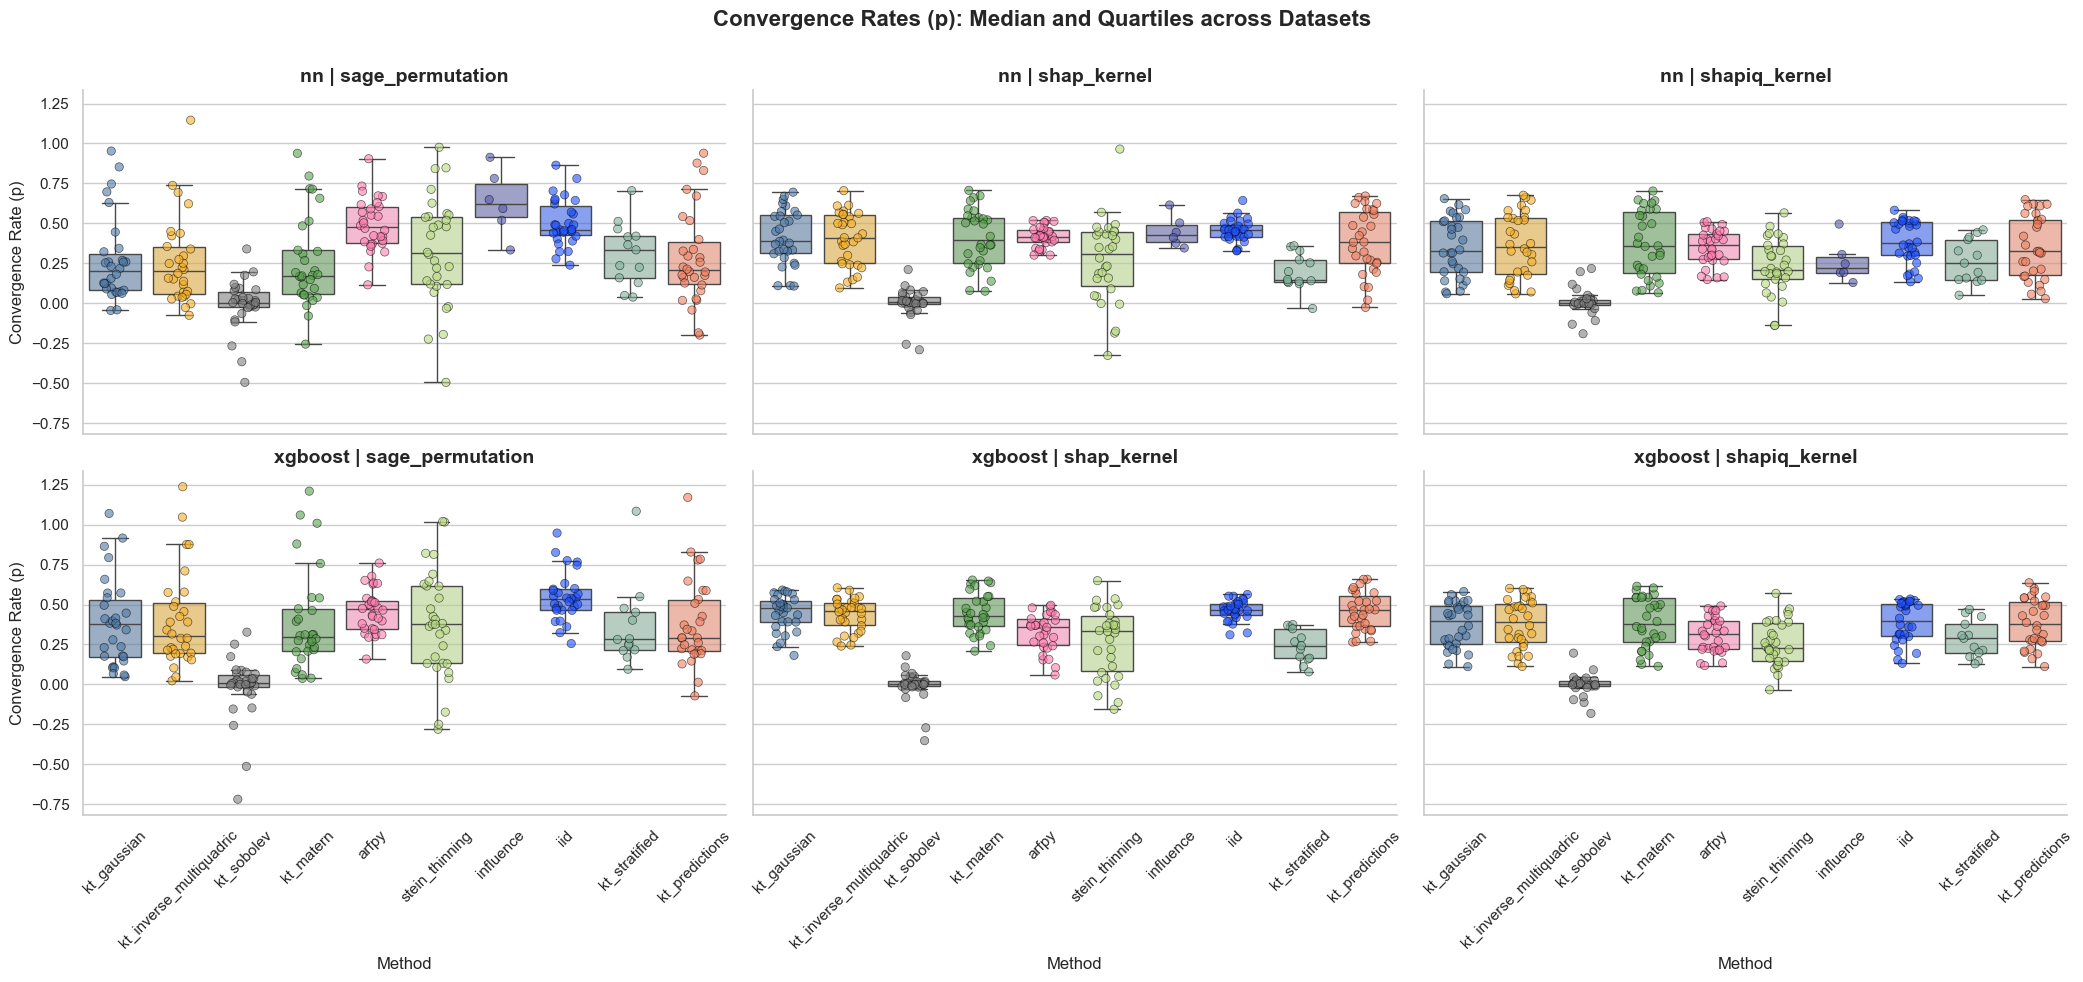

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

available_methods = coeffs_df_other["method_total"].unique()
method_order = [m for m in method_colors.keys() if m in available_methods]

g = sns.FacetGrid(
    coeffs_df_other, 
    col="explainer_total", 
    row="model_name", 
    sharey=True, 
    height=5, 
    aspect=1.4
)

def draw_boxplot_with_points(data, **kwargs):
    ax = plt.gca()
    
    sns.boxplot(
        data=data,
        x="method_total",
        y="p",
        order=method_order,
        palette=method_colors,
        fliersize=0,  
        linewidth=1,
        ax=ax
    )
    
    for patch in ax.patches:
        r, g_col, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g_col, b, 0.6))
    
    sns.stripplot(
        data=data,
        x="method_total",
        y="p",
        order=method_order,
        hue="method_total",
        palette=method_colors,
        jitter=0.2,
        size=6,
        alpha=0.6,
        edgecolor="black",
        linewidth=0.5,
        legend=False,
        ax=ax
    )

g.map_dataframe(draw_boxplot_with_points)

g.set_axis_labels("Method", "Convergence Rate (p)", fontsize=12)
g.set_titles(row_template="{row_name}", col_template="{col_name}", size=14, weight='bold')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.grid(False) 

plt.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Convergence Rates (p): Median and Quartiles across Datasets", fontsize=16, fontweight='bold')

plt.show()

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/1209602924.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/1209602924.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/1209602924.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/1209602924.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

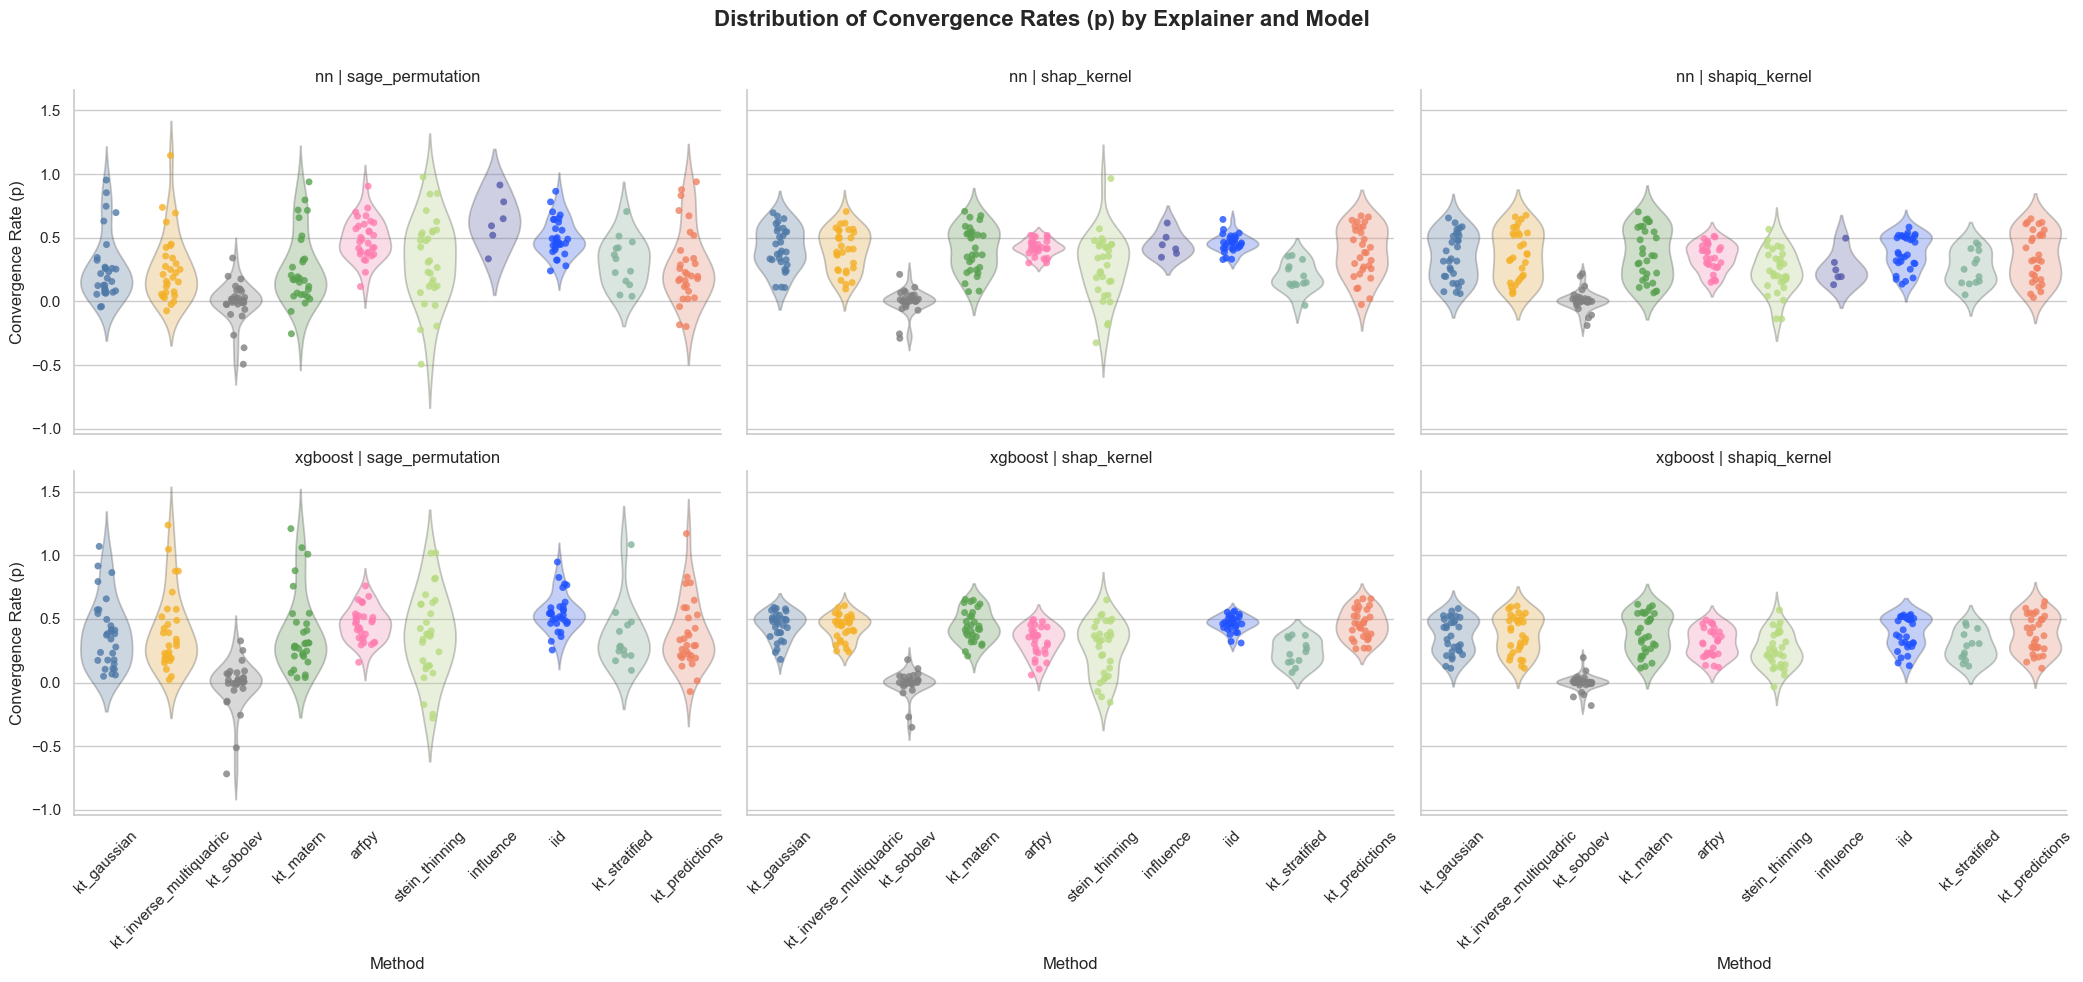

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
method_order = [m for m in method_colors.keys() if m in coeffs_df_other["method_total"].unique()]

g = sns.FacetGrid(
    coeffs_df_other, 
    col="explainer_total", 
    row="model_name", 
    sharey=True, 
    height=5, 
    aspect=1.4
)

def draw_violin_plots(data, **kwargs):
    ax = plt.gca()
    
    sns.violinplot(
        data=data,
        x="method_total",
        y="p",
        order=method_order,
        palette=method_colors,
        inner=None,
        alpha=0.3,
        ax=ax
    )
    
    sns.stripplot(
        data=data,
        x="method_total",
        y="p",
        order=method_order,
        hue="method_total",
        palette=method_colors,
        jitter=0.15,
        size=5,
        alpha=0.8,
        legend=False,
        ax=ax
    )

g.map_dataframe(draw_violin_plots)

g.set_axis_labels("Method", "Convergence Rate (p)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.grid(False)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribution of Convergence Rates (p) by Explainer and Model", fontsize=16, fontweight='bold')

plt.show()

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/2519498837.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


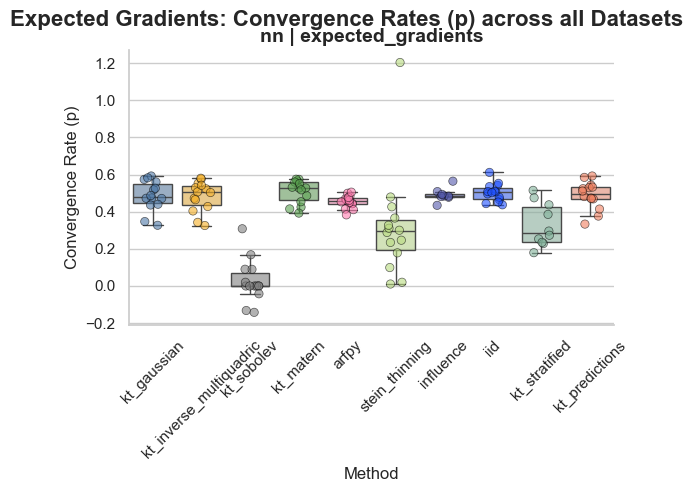

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

available_methods = coeffs_df_exp_grads["method_total"].unique()
method_order = [m for m in method_colors.keys() if m in available_methods]

g = sns.FacetGrid(
    coeffs_df_exp_grads, 
    col="explainer_total", 
    row="model_name", 
    sharey=True, 
    height=5, 
    aspect=1.2
)

def draw_boxplot_with_points(data, **kwargs):
    ax = plt.gca()
    
    sns.boxplot(
        data=data,
        x="method_total",
        y="p",
        order=method_order,
        palette=method_colors,
        fliersize=0,  
        linewidth=1,
        ax=ax
    )
    
    for patch in ax.patches:
        r, g_col, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g_col, b, 0.6))
    
    sns.stripplot(
        data=data,
        x="method_total",
        y="p",
        order=method_order,
        hue="method_total",
        palette=method_colors,
        jitter=0.2,
        size=6,
        alpha=0.6,
        edgecolor="black",
        linewidth=0.5,
        legend=False,
        ax=ax
    )

g.map_dataframe(draw_boxplot_with_points)

g.set_axis_labels("Method", "Convergence Rate (p)", fontsize=12)
g.set_titles(row_template="{row_name}", col_template="{col_name}", size=14, weight='bold')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.grid(False) 

plt.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Expected Gradients: Convergence Rates (p) across all Datasets", fontsize=16, fontweight='bold')

plt.show()

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_4343/326833041.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


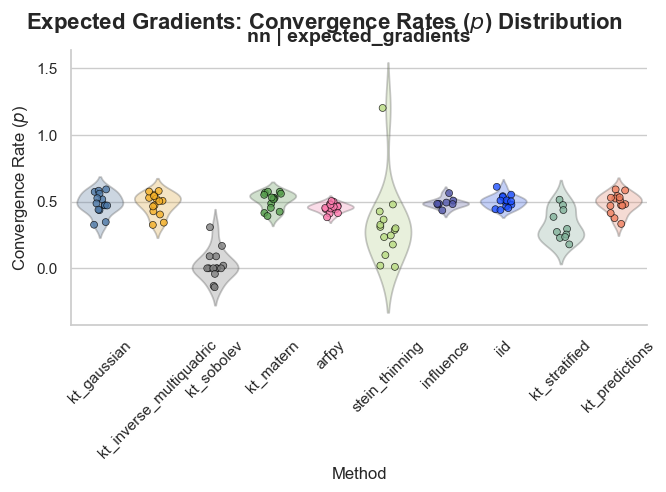

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

available_methods = coeffs_df_exp_grads["method_total"].unique()
method_order = [m for m in method_colors.keys() if m in available_methods]

g = sns.FacetGrid(
    coeffs_df_exp_grads, 
    col="explainer_total", 
    row="model_name", 
    sharey=True, 
    height=5, 
    aspect=1.4
)

def draw_violin_plots(data, **kwargs):
    ax = plt.gca()
    
    sns.violinplot(
        data=data,
        x="method_total",
        y="p",
        order=method_order,
        palette=method_colors,
        inner=None,
        alpha=0.3,
        ax=ax
    )
    
    sns.stripplot(
        data=data,
        x="method_total",
        y="p",
        order=method_order,
        hue="method_total",
        palette=method_colors,
        jitter=0.15,
        size=5,
        alpha=0.8,
        legend=False,
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

g.map_dataframe(draw_violin_plots)

g.set_axis_labels("Method", "Convergence Rate ($p$)", fontsize=12)
g.set_titles(row_template="{row_name}", col_template="{col_name}", size=14, weight='bold')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.grid(False)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Expected Gradients: Convergence Rates ($p$) Distribution", fontsize=16, fontweight='bold')

plt.show()

# analysis of model accuracy